#### EX for LinearRegression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
data={
    "Pizza_diameter":[8,10,12],
    "Price":[10,13,16]
}
df=pd.DataFrame(data)
df

,Pizza_diameter,Price
0,8,10
1,10,13
2,12,16


In [ ]:
X=df[['Pizza_diameter']]
y=df[['Price']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
new_diemeter=[[30]]
prediction=model.predict(new_diemeter)
print("Predicted Price :",prediction[0])

Predicted Price : [43.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## **Regression Matrix**

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import r2_score

In [ ]:
data={
    'Study_hours':[1,2,3,4,5,6,7,8],
    'Marks':[35,40,50,60,70,75,85,90]
}
df=pd.DataFrame(data)
df

,Study_hours,Marks
0,1,35
1,2,40
2,3,50
3,4,60
4,5,70
5,6,75
6,7,85
7,8,90


In [ ]:
X=df[['Study_hours']]
y=df[['Marks']]

In [ ]:
model=LinearRegression()
model.fit(X,y)

LinearRegression()

In [ ]:
y_pred=model.predict(X)
print("Predicted marks:",y_pred)

Predicted marks: [[34.16666667]
 [42.44047619]
 [50.71428571]
 [58.98809524]
 [67.26190476]
 [75.53571429]
 [83.80952381]
 [92.08333333]]


### MAE

In [ ]:
mae=mean_absolute_error(y, y_pred)
print("MAE :",mae)

MAE : 1.4434523809523805


### MSE

In [ ]:
mse = mean_squared_error(y,y_pred)
print("MSE :",mse)

MSE : 2.715773809523813


### RMSE

In [ ]:
rmse = np.sqrt(mean_squared_error(y,y_pred))
print("RMSE:",rmse)

RMSE: 1.6479604999889448


### R2_Score

In [ ]:
r2 = r2_score(y,y_pred)
print("R2_Score:",r2)

R2_Score: 0.9925001284224585


## **Multicollinearity**

In [ ]:
# Step 1 : Create a sample dataset

import pandas as pd
data={
    'House_size':[800,1000,1200,1400,1600],
    'bedroom':[2,3,3,4,5],
    'distance_city':[15,12,10,8,6],
    'price':[40,50,60,70,80]
}
df=pd.DataFrame(data)
df

,House_size,bedroom,distance_city,price
0,800,2,15,40
1,1000,3,12,50
2,1200,3,10,60
3,1400,4,8,70
4,1600,5,6,80


In [ ]:
# STEP 2 : Check correlation matrix
corr_matrix = df.corr()
print(corr_matrix)

               House_size   bedroom  distance_city     price
House_size       1.000000  0.970725      -0.995893  1.000000
bedroom          0.970725  1.000000      -0.966739  0.970725
distance_city   -0.995893 -0.966739       1.000000 -0.995893
price            1.000000  0.970725      -0.995893  1.000000


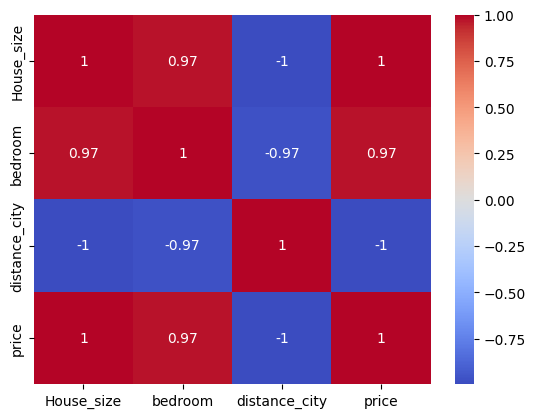

In [ ]:
# Visualize correlation
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Calculating VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

X=df[['House_size','bedroom','distance_city']]

X["Intercept"] = 1

vif_data=pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

         Feature          VIF
0     House_size   138.333333
1        bedroom    17.333333
2  distance_city   122.000000
3      Intercept  6874.166667
